# Notebook 02: Exploratory Data Analysis

### English

**Purpose**

- Characterize the dog and cat face images retrieved in `01_download_data.ipynb` across multiple dimensions: class balance, file size, brightness, blur, color composition, edge density, texture, and near-duplication.
- Compare these characteristics between the two species, since generation is conditioned on species and any systematic difference between classes is relevant to model design and evaluation.
- Identify outliers or data-quality issues (corrupt-looking images, extreme brightness/blur, duplicates) that should inform decisions in `03_preprocessing.ipynb`.

**Data Source**

- `data/raw/manifest.csv`, produced by `01_download_data.ipynb` — 10,892 validated images (5,239 dog, 5,653 cat), all 512×512 PNG/JPG files under `data/raw/images/`. This notebook reads exclusively from the manifest and the image files it references; it does not re-download or re-scan the file system from scratch.

**Execution Environment**

- Runs locally; GPU acceleration is not required.
- Most of this notebook processes the full 10,892-image set (brightness, blur, color, edge density, duplicate hashing are all computationally cheap per image). One section (texture analysis via Local Binary Patterns) instead uses a stratified random subsample, since it is markedly more expensive per image and a subsample is sufficient to characterize the distribution — this tradeoff is explained at that section.

**Pipeline Steps**

- [ ] 1. Environment verification and dependency installation
- [ ] 2. Load manifest and configure paths
- [ ] 3. Dataset overview and class balance
- [ ] 4. Full-dataset feature extraction (brightness, blur, color, edge density, perceptual hash)
- [ ] 5. Image size and file-size analysis
- [ ] 6. Brightness and blur distribution analysis
- [ ] 7. Color composition analysis
- [ ] 8. Edge density analysis
- [ ] 9. Texture analysis (Local Binary Patterns, subsample)
- [ ] 10. Duplicate and near-duplicate detection
- [ ] 11. Feature-space visualization (PCA, species separability)
- [ ] 12. Outlier sample inspection
- [ ] 13. Summary and implications for preprocessing

---

### Tiếng Việt

**Mục tiêu**

- Mô tả đặc điểm của tập ảnh mặt chó và mèo đã thu thập ở `01_download_data.ipynb` trên nhiều khía cạnh: cân bằng lớp, dung lượng file, độ sáng, độ mờ, thành phần màu sắc, mật độ cạnh, kết cấu (texture), và khả năng trùng lặp gần.
- So sánh các đặc điểm này giữa hai loài, vì việc sinh ảnh có điều kiện theo loài, nên bất kỳ khác biệt hệ thống nào giữa hai lớp đều liên quan đến thiết kế mô hình và đánh giá sau này.
- Xác định các điểm bất thường hoặc vấn đề chất lượng dữ liệu (ảnh có dấu hiệu hỏng, độ sáng/độ mờ cực đoan, ảnh trùng lặp) để làm cơ sở cho các quyết định ở `03_preprocessing.ipynb`.

**Nguồn dữ liệu**

- `data/raw/manifest.csv`, được tạo bởi `01_download_data.ipynb` — 10.892 ảnh đã qua kiểm tra hợp lệ (5.239 chó, 5.653 mèo), toàn bộ là file PNG/JPG 512×512 trong `data/raw/images/`. Notebook này chỉ đọc từ manifest và các file ảnh mà nó tham chiếu; không tải lại hay quét lại hệ thống tệp từ đầu.

**Môi trường thực thi**

- Chạy trên máy cục bộ (local); không yêu cầu GPU.
- Phần lớn notebook xử lý trên toàn bộ 10.892 ảnh (độ sáng, độ mờ, màu sắc, mật độ cạnh, hash trùng lặp đều có chi phí tính toán thấp trên mỗi ảnh). Một mục (phân tích texture bằng Local Binary Patterns) sử dụng một tập con lấy mẫu ngẫu nhiên có phân tầng, vì chi phí tính toán trên mỗi ảnh cao hơn đáng kể và một tập con là đủ để mô tả phân phối — sự đánh đổi này được giải thích cụ thể ở mục đó.

**Các bước trong pipeline**

- [ ] 1. Kiểm tra môi trường và cài đặt thư viện phụ thuộc
- [ ] 2. Tải manifest và thiết lập đường dẫn
- [ ] 3. Tổng quan dataset và cân bằng lớp
- [ ] 4. Trích xuất đặc trưng trên toàn bộ dataset (độ sáng, độ mờ, màu sắc, mật độ cạnh, perceptual hash)
- [ ] 5. Phân tích kích thước ảnh và dung lượng file
- [ ] 6. Phân tích phân phối độ sáng và độ mờ
- [ ] 7. Phân tích thành phần màu sắc
- [ ] 8. Phân tích mật độ cạnh
- [ ] 9. Phân tích texture (Local Binary Patterns, trên tập con)
- [ ] 10. Phát hiện ảnh trùng lặp và trùng lặp gần
- [ ] 11. Trực quan hóa không gian đặc trưng (PCA, khả năng phân tách theo loài)
- [ ] 12. Kiểm tra các ảnh bất thường (outlier)
- [ ] 13. Tổng kết và ý nghĩa đối với bước tiền xử lý


## 1. Environment Verification and Dependency Installation

### English

**Objective**

- Confirm that the Python packages required for this notebook are available.
- Automatically install any missing dependency.

---

### Tiếng Việt

**Mục tiêu**

- Xác nhận các thư viện Python cần thiết cho notebook đã sẵn sàng.
- Tự động cài đặt các thư viện còn thiếu.


In [1]:
import importlib
import subprocess
import sys

REQUIRED = ["cv2", "PIL", "pandas", "numpy", "matplotlib", "seaborn", "imagehash", "skimage", "sklearn", "tqdm"]
PIP_NAMES = {"cv2": "opencv-python", "PIL": "pillow", "skimage": "scikit-image", "sklearn": "scikit-learn"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAMES.get(mod, mod))

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages are already available.")


Installing missing packages: ['imagehash']


## 2. Load Manifest and Configure Paths

### English

**Objective**

- Resolve the project root directory relative to the notebook's location.
- Load `data/raw/manifest.csv` and confirm it matches the state left by notebook 01.

**Output**

- `manifest`: a DataFrame with one row per image (`filepath`, `species`, `filesize_kb`, `width`, `height`, `is_valid`, `error`).

---

### Tiếng Việt

**Mục tiêu**

- Xác định thư mục gốc của dự án dựa trên vị trí của notebook.
- Tải `data/raw/manifest.csv` và xác nhận nó khớp với trạng thái để lại từ notebook 01.

**Kết quả**

- `manifest`: một DataFrame với mỗi dòng là một ảnh (`filepath`, `species`, `filesize_kb`, `width`, `height`, `is_valid`, `error`).


In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "02_eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(DATA_RAW / "manifest.csv")
manifest = manifest[manifest["is_valid"]].reset_index(drop=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Figures dir  : {FIGURES_DIR}")
print(f"Manifest rows: {len(manifest)}")
manifest.head()


Project root : d:\Images by GAN\dog-gan-project
Figures dir  : d:\Images by GAN\dog-gan-project\reports\figures\02_eda
Manifest rows: 10892


,filepath,species,filesize_kb,width,height,is_valid,error
0,data\raw\images\cat_00000_flickr_cat_000002.jpg,cat,26.7,512,512,True,NaN
1,data\raw\images\cat_00001_flickr_cat_000003.jpg,cat,35.1,512,512,True,NaN
2,data\raw\images\cat_00002_flickr_cat_000004.jpg,cat,43.4,512,512,True,NaN
3,data\raw\images\cat_00003_flickr_cat_000005.jpg,cat,40.1,512,512,True,NaN
4,data\raw\images\cat_00004_flickr_cat_000006.jpg,cat,46.2,512,512,True,NaN


## 3. Dataset Overview and Class Balance

### English

**Objective**

- Quantify and visualize the number of images per species.

**Notes**

- A 47.9% dog / 51.9% cat split (approximately) is close enough to balanced that no class-weighting or resampling strategy is anticipated to be necessary for conditional training in `04_model_training.ipynb`; this chart exists to confirm that assumption numerically rather than by inspection of raw counts alone.

**Output**

- `reports/figures/02_eda/03_class_balance.png`

---

### Tiếng Việt

**Mục tiêu**

- Định lượng và trực quan hóa số lượng ảnh theo từng loài.

**Lưu ý**

- Tỷ lệ chó/mèo xấp xỉ 47.9%/51.9% là đủ cân bằng để không cần chiến lược class-weighting hay resampling nào cho việc huấn luyện có điều kiện ở `04_model_training.ipynb`; biểu đồ này tồn tại để xác nhận giả định đó bằng số liệu thay vì chỉ dựa vào việc nhìn số đếm thô.

**Kết quả**

- `reports/figures/02_eda/03_class_balance.png`


Image count by species:
species
cat    5653
dog    5239
Name: count, dtype: int64

Percentage by species:
species
cat    51.9
dog    48.1
Name: count, dtype: float64


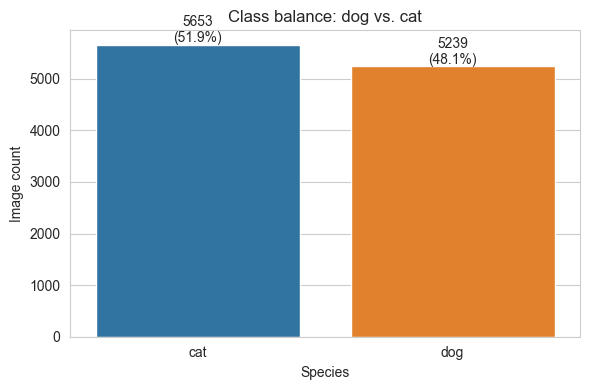

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

species_counts = manifest["species"].value_counts()
species_pct = (species_counts / species_counts.sum() * 100).round(1)

print("Image count by species:")
print(species_counts)
print("\nPercentage by species:")
print(species_pct)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=species_counts.index, y=species_counts.values, ax=ax, hue=species_counts.index, legend=False)
for i, (count, pct) in enumerate(zip(species_counts.values, species_pct.values)):
    ax.text(i, count + 50, f"{count}\n({pct}%)", ha="center")
ax.set_xlabel("Species")
ax.set_ylabel("Image count")
ax.set_title("Class balance: dog vs. cat")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_class_balance.png", dpi=150)
plt.show()


## 4. Full-Dataset Feature Extraction

### English

**Objective**

- Compute, for every image, a set of cheap-to-derive quantitative features used throughout the rest of this notebook: brightness, blur, mean color per channel, edge density, and a perceptual hash.

**Notes**

- All five features are derived from a single image read per file, rather than re-reading each image separately for each analysis section — this keeps the total I/O and decode cost to one pass over the dataset.
- **Brightness**: mean pixel intensity of the grayscale-converted image (0-255 scale).
- **Blur**: variance of the Laplacian of the grayscale image — a standard, widely-used proxy for sharpness; low variance indicates a lack of high-frequency detail (blur), while high variance indicates a sharp, detailed image.
- **Mean color**: the per-channel (R, G, B) mean pixel value, giving a coarse summary of each image's color composition.
- **Edge density**: the fraction of pixels flagged as edges by the Canny edge detector — a coarse structural-complexity signal, distinct from the differentiable Sobel/Laplacian channels used inside the GAN training loop (this one is only for exploratory analysis and uses non-differentiable operations, consistent with the project's earlier decision to keep Canny EDA-only).
- **Perceptual hash**: a 64-bit perceptual hash (`phash`) computed from each image, used later in Section 10 to detect exact and near-duplicate images.

**Output**

- `features`: a DataFrame merged with `manifest`, with one additional row per image containing `brightness`, `blur`, `mean_r`, `mean_g`, `mean_b`, `edge_density`, and `phash`.

---

### Tiếng Việt

**Mục tiêu**

- Tính toán, cho từng ảnh, một tập đặc trưng định lượng có chi phí tính toán thấp, được dùng xuyên suốt phần còn lại của notebook: độ sáng, độ mờ, màu trung bình theo từng kênh, mật độ cạnh, và perceptual hash.

**Lưu ý**

- Cả 5 đặc trưng đều được tính từ một lần đọc ảnh duy nhất cho mỗi file, thay vì đọc lại ảnh riêng cho từng mục phân tích — giúp chi phí I/O và giải mã chỉ tốn một lượt quét qua toàn bộ dataset.
- **Độ sáng (brightness)**: giá trị pixel trung bình của ảnh sau khi chuyển sang thang xám (0-255).
- **Độ mờ (blur)**: phương sai của Laplacian trên ảnh xám — một chỉ số phổ biến, tiêu chuẩn để đo độ sắc nét; phương sai thấp cho thấy thiếu chi tiết tần số cao (ảnh mờ), phương sai cao cho thấy ảnh sắc nét, nhiều chi tiết.
- **Màu trung bình**: giá trị pixel trung bình theo từng kênh (R, G, B), cho một tóm tắt sơ bộ về thành phần màu của mỗi ảnh.
- **Mật độ cạnh**: tỷ lệ pixel được Canny edge detector đánh dấu là cạnh — một tín hiệu thô về độ phức tạp cấu trúc, khác với các kênh Sobel/Laplacian khả vi dùng trong vòng lặp huấn luyện GAN (kênh này chỉ dùng cho phân tích khám phá, dùng các phép toán không khả vi, nhất quán với quyết định trước đó của dự án là chỉ dùng Canny cho EDA).
- **Perceptual hash**: một hash tri giác 64-bit (`phash`) tính cho mỗi ảnh, dùng ở Mục 10 để phát hiện ảnh trùng lặp chính xác và trùng lặp gần.

**Kết quả**

- `features`: một DataFrame gộp với `manifest`, thêm mỗi ảnh các cột `brightness`, `blur`, `mean_r`, `mean_g`, `mean_b`, `edge_density`, và `phash`.


In [4]:
import cv2
import numpy as np
from PIL import Image
import imagehash
from tqdm.auto import tqdm

records = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Extracting features"):
    img_path = PROJECT_ROOT / row["filepath"]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    brightness = float(gray.mean())
    blur = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    mean_r, mean_g, mean_b = img_rgb.reshape(-1, 3).mean(axis=0)
    edges = cv2.Canny(gray, 100, 200)
    edge_density = float((edges > 0).mean())
    phash = str(imagehash.phash(Image.fromarray(img_rgb)))

    records.append({
        "filepath": row["filepath"],
        "brightness": brightness,
        "blur": blur,
        "mean_r": float(mean_r),
        "mean_g": float(mean_g),
        "mean_b": float(mean_b),
        "edge_density": edge_density,
        "phash": phash,
    })

feature_df = pd.DataFrame(records)
features = manifest.merge(feature_df, on="filepath", how="inner")
print(f"Feature extraction complete for {len(features)} images.")
features.head()


Extracting features:   0%|          | 0/10892 [00:00<?, ?it/s]

Feature extraction complete for 10892 images.


,filepath,species,filesize_kb,width,height,is_valid,error,brightness,blur,mean_r,mean_g,mean_b,edge_density,phash
0,data\raw\images\cat_00000_flickr_cat_000002.jpg,cat,26.7,512,512,True,NaN,37.586441,116.299659,39.049721,37.773727,32.619888,0.027832,c0229d3c3e1f372d
1,data\raw\images\cat_00001_flickr_cat_000003.jpg,cat,35.1,512,512,True,NaN,107.445770,965.421220,116.653389,105.813721,91.708538,0.055576,fa2a97c59463b164
2,data\raw\images\cat_00002_flickr_cat_000004.jpg,cat,43.4,512,512,True,NaN,105.508011,2371.112721,110.633583,104.424599,97.659111,0.077412,ffbac2d184e16c28
3,data\raw\images\cat_00003_flickr_cat_000005.jpg,cat,40.1,512,512,True,NaN,96.301994,1184.327845,93.215023,96.443832,103.763954,0.062881,9feb87c091669c2c
4,data\raw\images\cat_00004_flickr_cat_000006.jpg,cat,46.2,512,512,True,NaN,99.412209,2871.666533,93.932934,100.388748,108.864693,0.088127,8eeab3c7a4b27130


## 5. Image Size and File-Size Analysis

### English

**Objective**

- Confirm image dimensions are uniform (as already established in notebook 01) and analyze the distribution of file sizes, by species.

**Notes**

- All images were already confirmed to be exactly 512×512 in notebook 01; this section focuses on file-size variation instead, which reflects compression/detail differences between images even at fixed resolution and can hint at content complexity differences between species.

**Output**

- `reports/figures/02_eda/05_filesize_distribution.png`

---

### Tiếng Việt

**Mục tiêu**

- Xác nhận kích thước ảnh đồng nhất (đã xác nhận ở notebook 01) và phân tích phân phối dung lượng file, theo từng loài.

**Lưu ý**

- Toàn bộ ảnh đã được xác nhận chính xác 512×512 ở notebook 01; mục này tập trung vào biến động dung lượng file thay vào đó, phản ánh sự khác biệt về nén/chi tiết giữa các ảnh dù cùng độ phân giải, và có thể gợi ý khác biệt về độ phức tạp nội dung giữa hai loài.

**Kết quả**

- `reports/figures/02_eda/05_filesize_distribution.png`


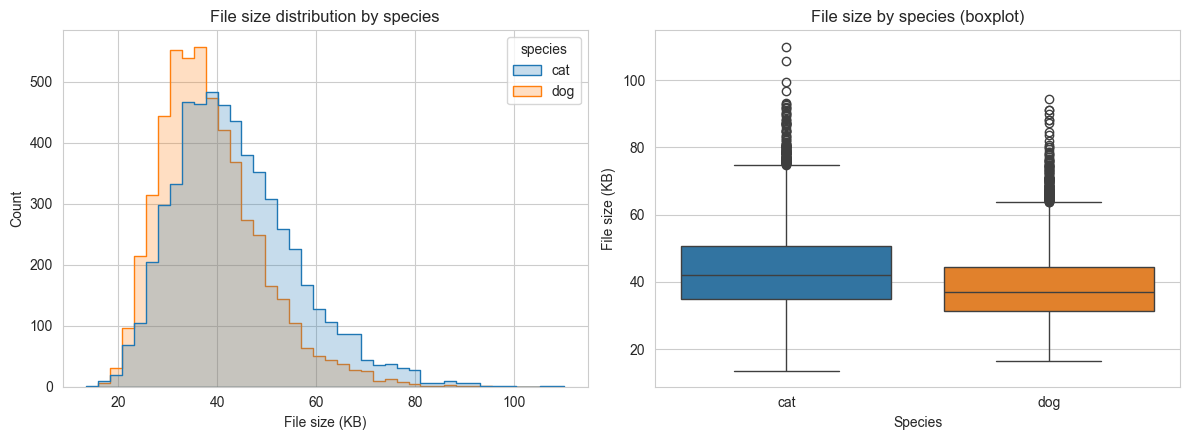

          count       mean        std   min   25%   50%   75%    max
species                                                             
cat      5653.0  43.783832  12.414449  13.6  34.8  42.1  50.8  110.0
dog      5239.0  38.738576  10.392535  16.3  31.3  37.0  44.3   94.4


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=features, x="filesize_kb", hue="species", element="step", bins=40, ax=axes[0])
axes[0].set_title("File size distribution by species")
axes[0].set_xlabel("File size (KB)")

sns.boxplot(data=features, x="species", y="filesize_kb", hue="species", legend=False, ax=axes[1])
axes[1].set_title("File size by species (boxplot)")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("File size (KB)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_filesize_distribution.png", dpi=150)
plt.show()

print(features.groupby("species")["filesize_kb"].describe())


## 6. Brightness and Blur Distribution Analysis

### English

**Objective**

- Visualize the distribution of brightness and blur across the dataset, by species, and identify their joint relationship.

**Notes**

- Extreme values on either metric (very dark/bright images, or very low blur-variance images) are candidate outliers worth inspecting visually in Section 12, and may inform an exclusion threshold in `03_preprocessing.ipynb` if a meaningful tail of low-quality images is present.

**Output**

- `reports/figures/02_eda/06_brightness_blur_distribution.png`
- `reports/figures/02_eda/06_brightness_vs_blur_scatter.png`

---

### Tiếng Việt

**Mục tiêu**

- Trực quan hóa phân phối độ sáng và độ mờ trên toàn dataset, theo từng loài, và xác định mối quan hệ giữa chúng.

**Lưu ý**

- Các giá trị cực đoan ở một trong hai chỉ số (ảnh quá tối/quá sáng, hoặc ảnh có phương sai blur quá thấp) là các outlier tiềm năng đáng kiểm tra trực quan ở Mục 12, và có thể làm cơ sở cho một ngưỡng loại bỏ ở `03_preprocessing.ipynb` nếu tồn tại một lượng đáng kể ảnh chất lượng thấp.

**Kết quả**

- `reports/figures/02_eda/06_brightness_blur_distribution.png`
- `reports/figures/02_eda/06_brightness_vs_blur_scatter.png`


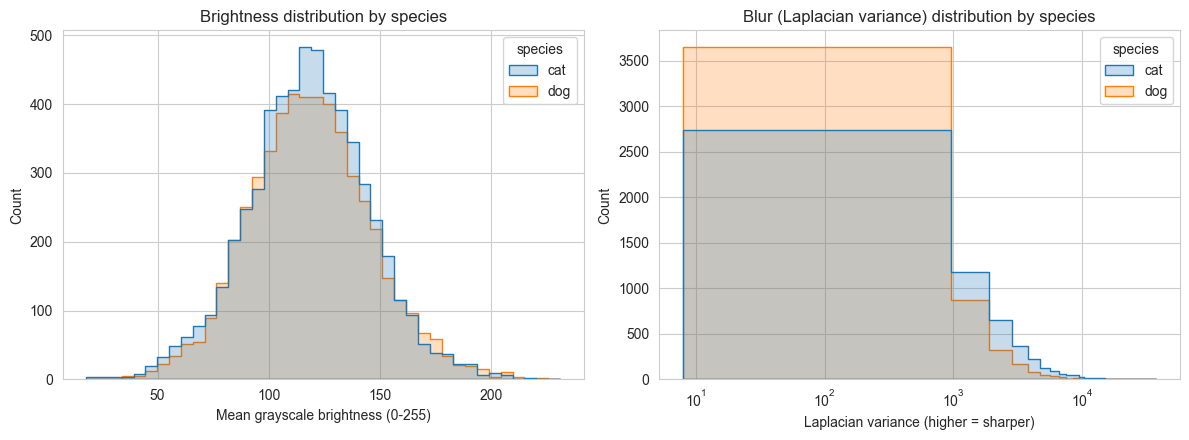

        brightness                                                            \
             count        mean        std        min         25%         50%   
species                                                                        
cat         5653.0  118.065738  27.280544  17.865883  100.582928  118.157158   
dog         5239.0  118.791588  27.348922  25.880554  100.344015  117.993576   

                                   blur                                       \
                75%         max   count         mean          std        min   
species                                                                        
cat      135.604343  231.169289  5653.0  1873.444877  2571.030779   7.862930   
dog      136.108253  221.629898  5239.0  1008.610465  1561.973947  12.698627   

                                                            
                25%         50%          75%           max  
species                                                     
cat      415.88

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=features, x="brightness", hue="species", element="step", bins=40, ax=axes[0])
axes[0].set_title("Brightness distribution by species")
axes[0].set_xlabel("Mean grayscale brightness (0-255)")

sns.histplot(data=features, x="blur", hue="species", element="step", bins=40, ax=axes[1])
axes[1].set_title("Blur (Laplacian variance) distribution by species")
axes[1].set_xlabel("Laplacian variance (higher = sharper)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_brightness_blur_distribution.png", dpi=150)
plt.show()

print(features.groupby("species")[["brightness", "blur"]].describe())


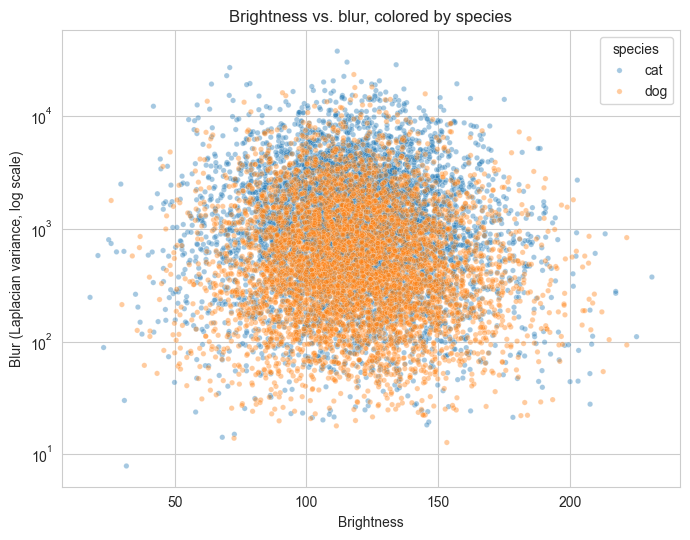

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=features, x="brightness", y="blur", hue="species", alpha=0.4, s=15, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Brightness")
ax.set_ylabel("Blur (Laplacian variance, log scale)")
ax.set_title("Brightness vs. blur, colored by species")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_brightness_vs_blur_scatter.png", dpi=150)
plt.show()


## 7. Color Composition Analysis

### English

**Objective**

- Compare the aggregate color composition of dog images versus cat images, via per-channel mean-color distributions and a per-species "average image."

**Notes**

- The average image (the pixel-wise mean of all images in a species, after resizing to a common small size for this visualization only) is a coarse but intuitive way to see systematic composition differences — e.g. typical framing, background tone, or color cast — between the two species' photo collections.

**Output**

- `reports/figures/02_eda/07_color_histograms.png`
- `reports/figures/02_eda/07_average_images.png`

---

### Tiếng Việt

**Mục tiêu**

- So sánh thành phần màu sắc tổng hợp giữa ảnh chó và ảnh mèo, thông qua phân phối màu trung bình theo từng kênh và một "ảnh trung bình" cho mỗi loài.

**Lưu ý**

- Ảnh trung bình (trung bình theo từng pixel của toàn bộ ảnh trong một loài, sau khi resize về một kích thước nhỏ chung chỉ để phục vụ trực quan hóa này) là một cách thô nhưng trực quan để thấy khác biệt hệ thống về bố cục — ví dụ khung hình điển hình, tông nền, hoặc thiên hướng màu — giữa bộ ảnh của hai loài.

**Kết quả**

- `reports/figures/02_eda/07_color_histograms.png`
- `reports/figures/02_eda/07_average_images.png`


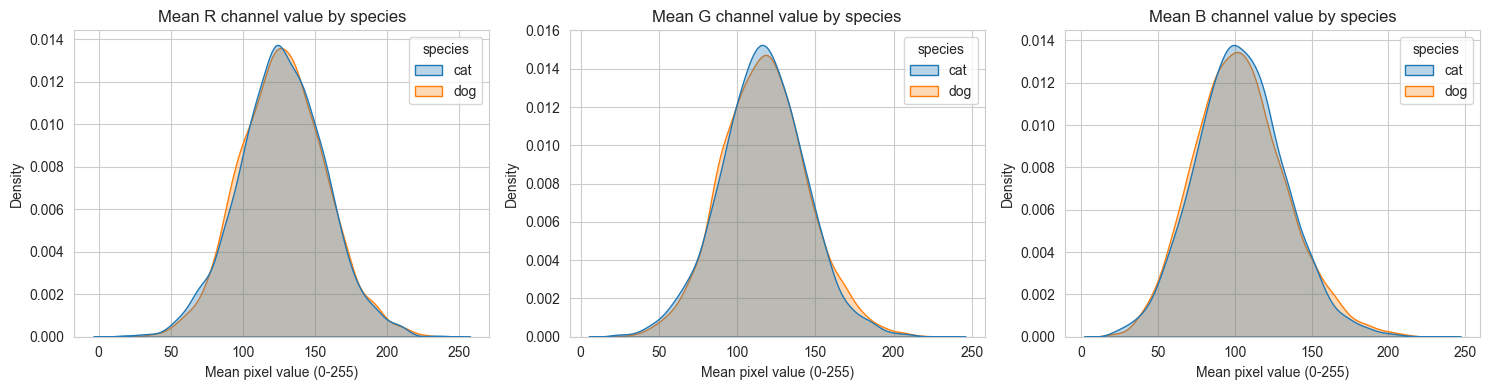

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, channel, color in zip(axes, ["mean_r", "mean_g", "mean_b"], ["r", "g", "b"]):
    sns.kdeplot(data=features, x=channel, hue="species", ax=ax, fill=True, alpha=0.3, common_norm=False)
    ax.set_title(f"Mean {color.upper()} channel value by species")
    ax.set_xlabel("Mean pixel value (0-255)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_color_histograms.png", dpi=150)
plt.show()


Averaging:   0%|          | 0/5653 [00:00<?, ?it/s]

Averaging:   0%|          | 0/5239 [00:00<?, ?it/s]

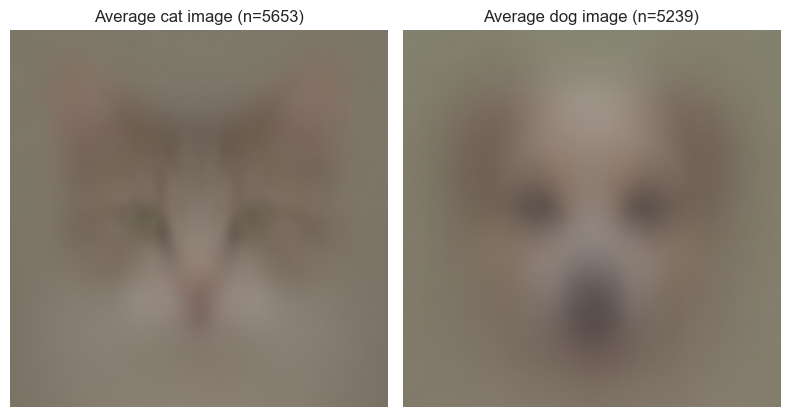

In [9]:
AVERAGE_IMAGE_SIZE = (128, 128)  # downsized only for this aggregate visualization

def compute_average_image(filepaths, size=AVERAGE_IMAGE_SIZE):
    accumulator = np.zeros((size[1], size[0], 3), dtype=np.float64)
    for fp in tqdm(filepaths, desc="Averaging", leave=False):
        img = cv2.imread(str(PROJECT_ROOT / fp))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        accumulator += img
    return (accumulator / len(filepaths)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
for ax, species in zip(axes, sorted(features["species"].unique())):
    paths = features.loc[features["species"] == species, "filepath"]
    avg_img = compute_average_image(paths)
    ax.imshow(avg_img)
    ax.set_title(f"Average {species} image (n={len(paths)})")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_average_images.png", dpi=150)
plt.show()


## 8. Edge Density Analysis

### English

**Objective**

- Compare the distribution of Canny edge density between species, as a coarse proxy for structural/textural complexity.

**Notes**

- Higher edge density broadly correlates with more fine detail (fur texture, whiskers) or background clutter; this section is exploratory context for the Discriminator auxiliary-channel ablation study (Sobel/Laplacian, used inside training) rather than a direct input to it.

**Output**

- `reports/figures/02_eda/08_edge_density.png`

---

### Tiếng Việt

**Mục tiêu**

- So sánh phân phối mật độ cạnh (Canny) giữa hai loài, như một chỉ số thô cho độ phức tạp cấu trúc/texture.

**Lưu ý**

- Mật độ cạnh cao nhìn chung tương quan với nhiều chi tiết nhỏ hơn (kết cấu lông, ria) hoặc nền phức tạp hơn; mục này mang tính bối cảnh khám phá cho nghiên cứu ablation kênh phụ của Discriminator (Sobel/Laplacian, dùng trong huấn luyện) chứ không phải đầu vào trực tiếp cho nó.

**Kết quả**

- `reports/figures/02_eda/08_edge_density.png`


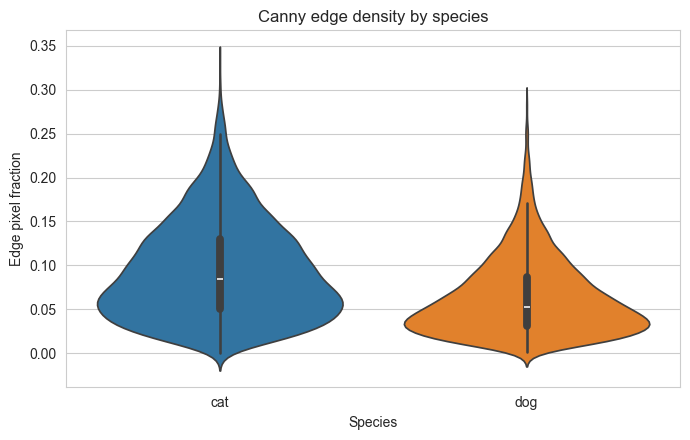

          count      mean       std      min       25%       50%       75%  \
species                                                                      
cat      5653.0  0.093789  0.055708  0.00000  0.050098  0.084312  0.129929   
dog      5239.0  0.063982  0.044036  0.00074  0.031061  0.052937  0.087023   

              max  
species            
cat      0.329346  
dog      0.286781  


In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(data=features, x="species", y="edge_density", hue="species", legend=False, ax=ax)
ax.set_title("Canny edge density by species")
ax.set_xlabel("Species")
ax.set_ylabel("Edge pixel fraction")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_edge_density.png", dpi=150)
plt.show()

print(features.groupby("species")["edge_density"].describe())


## 9. Texture Analysis (Local Binary Patterns, Subsample)

### English

**Objective**

- Characterize texture differences between species using Local Binary Patterns (LBP), computed on a stratified random subsample rather than the full dataset.

**Notes**

- LBP is markedly more expensive per image than the Section 4 features (it computes a per-pixel local comparison code across the whole image), so this section uses a stratified random subsample of 1,000 images per species (2,000 total) instead of all 10,892 — sufficient to characterize the distribution shape without a prohibitively long runtime.
- LBP is, like Canny, a non-differentiable/discrete-valued feature (uniform-pattern binning), so — consistent with the project's earlier decision — it is used here for exploratory analysis only, never as a Discriminator input during GAN training.
- The summary statistic reported per image is the Shannon entropy of its LBP histogram: higher entropy indicates a more varied local texture (e.g. fur), lower entropy indicates more uniform regions (e.g. flat background or skin).

**Output**

- `reports/figures/02_eda/09_lbp_entropy.png`

---

### Tiếng Việt

**Mục tiêu**

- Mô tả khác biệt về texture giữa hai loài bằng Local Binary Patterns (LBP), tính trên một tập con lấy mẫu ngẫu nhiên có phân tầng thay vì toàn bộ dataset.

**Lưu ý**

- LBP có chi phí tính toán trên mỗi ảnh cao hơn đáng kể so với các đặc trưng ở Mục 4 (nó tính một mã so sánh cục bộ cho từng pixel trên toàn ảnh), nên mục này dùng một tập con lấy mẫu phân tầng gồm 1.000 ảnh mỗi loài (tổng 2.000) thay vì toàn bộ 10.892 ảnh — đủ để mô tả hình dạng phân phối mà không tốn thời gian chạy quá lâu.
- Giống Canny, LBP là một đặc trưng không khả vi/giá trị rời rạc (phân bin theo uniform pattern), nên — nhất quán với quyết định trước đó của dự án — nó chỉ được dùng cho phân tích khám phá ở đây, không bao giờ dùng làm đầu vào cho Discriminator trong lúc huấn luyện GAN.
- Chỉ số tổng hợp báo cáo cho mỗi ảnh là entropy Shannon của histogram LBP: entropy cao cho thấy texture cục bộ đa dạng hơn (ví dụ lông), entropy thấp cho thấy vùng đồng nhất hơn (ví dụ nền phẳng hoặc da).

**Kết quả**

- `reports/figures/02_eda/09_lbp_entropy.png`


LBP subsample size: 2000 ({'cat': 1000, 'dog': 1000})


Computing LBP:   0%|          | 0/2000 [00:00<?, ?it/s]

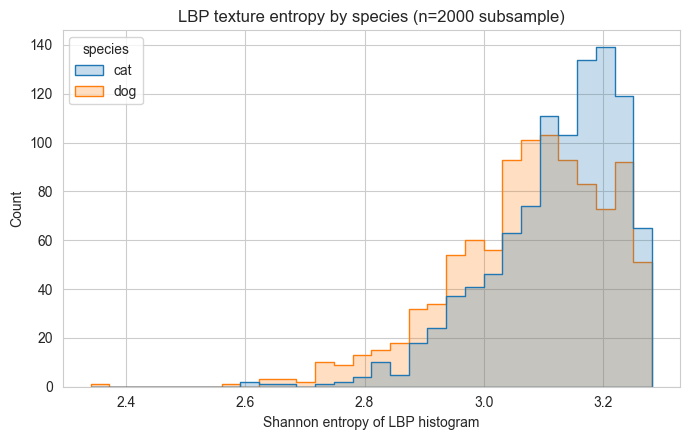

          count      mean       std       min       25%       50%       75%  \
species                                                                       
cat      1000.0  3.121231  0.109818  2.604159  3.059959  3.143781  3.204238   
dog      1000.0  3.076350  0.131180  2.340114  2.998660  3.092908  3.177310   

              max  
species            
cat      3.279419  
dog      3.282433  


In [11]:
from skimage.feature import local_binary_pattern

LBP_SAMPLE_PER_SPECIES = 1000
LBP_P, LBP_R = 8, 1

rng = np.random.default_rng(42)
sample_frames = []
for species, group in features.groupby("species"):
    n = min(LBP_SAMPLE_PER_SPECIES, len(group))
    sample_frames.append(group.sample(n=n, random_state=42))
lbp_sample = pd.concat(sample_frames, ignore_index=True)
print(f"LBP subsample size: {len(lbp_sample)} ({lbp_sample['species'].value_counts().to_dict()})")

lbp_entropies = []
for _, row in tqdm(lbp_sample.iterrows(), total=len(lbp_sample), desc="Computing LBP"):
    img_path = PROJECT_ROOT / row["filepath"]
    gray = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, P=LBP_P, R=LBP_R, method="uniform")
    hist, _ = np.histogram(lbp, bins=np.arange(0, LBP_P + 3), density=True)
    entropy = float(-np.sum(hist * np.log2(hist + 1e-10)))
    lbp_entropies.append(entropy)

lbp_sample = lbp_sample.copy()
lbp_sample["lbp_entropy"] = lbp_entropies

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=lbp_sample, x="lbp_entropy", hue="species", element="step", bins=30, ax=ax)
ax.set_title(f"LBP texture entropy by species (n={len(lbp_sample)} subsample)")
ax.set_xlabel("Shannon entropy of LBP histogram")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_lbp_entropy.png", dpi=150)
plt.show()

print(lbp_sample.groupby("species")["lbp_entropy"].describe())


## 10. Duplicate and Near-Duplicate Detection

### English

**Objective**

- Detect exact duplicate images (identical perceptual hash) and near-duplicate images (small Hamming distance between hashes) within the dataset, per species.

**Notes**

- Exact-duplicate detection is a simple dictionary lookup on the `phash` column computed in Section 4 (O(n) in the number of images).
- Near-duplicate detection compares every pair of hashes within the same species (computing pairwise Hamming distance between hash bit-arrays via `scipy.spatial.distance.pdist`), flagging pairs at or below a small distance threshold as likely near-duplicates (e.g. slightly cropped or re-compressed versions of the same source photo). This is restricted to within-species comparison, since a near-duplicate across species is not expected and would only inflate the comparison cost.
- Any duplicates found are candidates for removal in `03_preprocessing.ipynb`, since duplicated training images can bias the learned distribution and inflate apparent sample diversity.

**Output**

- Duplicate/near-duplicate counts, printed per species.

---

### Tiếng Việt

**Mục tiêu**

- Phát hiện ảnh trùng lặp chính xác (perceptual hash giống hệt nhau) và trùng lặp gần (khoảng cách Hamming nhỏ giữa các hash) trong dataset, theo từng loài.

**Lưu ý**

- Phát hiện trùng lặp chính xác là một phép tra cứu dictionary đơn giản trên cột `phash` đã tính ở Mục 4 (độ phức tạp O(n) theo số lượng ảnh).
- Phát hiện trùng lặp gần so sánh từng cặp hash trong cùng một loài (tính khoảng cách Hamming theo cặp giữa các mảng bit hash qua `scipy.spatial.distance.pdist`), đánh dấu các cặp có khoảng cách nhỏ hơn hoặc bằng một ngưỡng nhỏ là khả năng trùng lặp gần (ví dụ phiên bản crop nhẹ hoặc nén lại của cùng một ảnh gốc). Việc so sánh chỉ giới hạn trong cùng loài, vì trùng lặp gần giữa hai loài khác nhau không được kỳ vọng xảy ra và chỉ làm tăng chi phí so sánh không cần thiết.
- Mọi trùng lặp phát hiện được là ứng viên để loại bỏ ở `03_preprocessing.ipynb`, vì ảnh huấn luyện bị trùng lặp có thể làm lệch phân phối học được và làm phóng đại độ đa dạng mẫu biểu kiến.

**Kết quả**

- Số lượng ảnh trùng lặp/trùng lặp gần, in ra theo từng loài.


In [12]:
exact_dup_groups = features.groupby("phash")["filepath"].apply(list)
exact_dup_groups = exact_dup_groups[exact_dup_groups.apply(len) > 1]

print(f"Exact-duplicate hash groups found: {len(exact_dup_groups)}")
n_exact_dup_images = sum(len(v) - 1 for v in exact_dup_groups)  # extras beyond the first copy
print(f"Images that are exact duplicates of another image: {n_exact_dup_images}")
if len(exact_dup_groups) > 0:
    print("\nSample duplicate groups:")
    for phash_val, paths in list(exact_dup_groups.items())[:5]:
        print(f"  {phash_val}: {paths}")


Exact-duplicate hash groups found: 5
Images that are exact duplicates of another image: 5

Sample duplicate groups:
  807cb79c9d8c1d39: ['data\\raw\\images\\cat_02238_pixabay_cat_001661.jpg', 'data\\raw\\images\\cat_04693_pixabay_cat_004326.jpg']
  8a907a9fe42533b6: ['data\\raw\\images\\cat_02395_pixabay_cat_001828.jpg', 'data\\raw\\images\\cat_04936_pixabay_cat_004593.jpg']
  91c1606767765756: ['data\\raw\\images\\cat_01369_pixabay_cat_000709.jpg', 'data\\raw\\images\\cat_03584_pixabay_cat_003118.jpg']
  ab8fd6d2a0707075: ['data\\raw\\images\\cat_00246_flickr_cat_000280.jpg', 'data\\raw\\images\\cat_00249_flickr_cat_000284.jpg']
  cab6bbcc10e4a63c: ['data\\raw\\images\\cat_02393_pixabay_cat_001826.jpg', 'data\\raw\\images\\cat_02423_pixabay_cat_001856.jpg']


In [13]:
from scipy.spatial.distance import pdist, squareform

NEAR_DUP_THRESHOLD = 5  # Hamming distance, out of 64 bits -- small enough to indicate near-identical images

def hash_to_bits(hash_str, n_bits=64):
    return np.array([int(b) for b in bin(int(hash_str, 16))[2:].zfill(n_bits)], dtype=np.uint8)

near_dup_summary = {}
for species, group in features.groupby("species"):
    bit_matrix = np.stack([hash_to_bits(h) for h in group["phash"]])
    distances = pdist(bit_matrix, metric="hamming") * bit_matrix.shape[1]  # convert fraction back to bit count
    n_near_dup_pairs = int((distances <= NEAR_DUP_THRESHOLD).sum())
    near_dup_summary[species] = {
        "n_images": len(group),
        "n_pairs_compared": len(distances),
        "n_near_duplicate_pairs": n_near_dup_pairs,
    }

for species, stats in near_dup_summary.items():
    print(f"{species}: {stats['n_near_duplicate_pairs']} near-duplicate pairs "
          f"out of {stats['n_pairs_compared']} pairs compared "
          f"({stats['n_images']} images, Hamming distance <= {NEAR_DUP_THRESHOLD})")


cat: 60 near-duplicate pairs out of 15975378 pairs compared (5653 images, Hamming distance <= 5)
dog: 15 near-duplicate pairs out of 13720941 pairs compared (5239 images, Hamming distance <= 5)


## 11. Feature-Space Visualization (PCA, Species Separability)

### English

**Objective**

- Combine the per-image features computed in Section 4 into a single feature vector per image, and visualize their distribution in two dimensions via Principal Component Analysis (PCA), colored by species.

**Notes**

- This is a synthesis step: rather than reading each feature in isolation, it checks whether the two species are already separable using simple, hand-crafted statistics (brightness, blur, mean color, edge density) alone — without any learned representation. A visually distinct separation supports the choice of species-conditioning in the GAN architecture, since it suggests the two classes have systematically different low-level visual statistics.
- Features are standardized (zero mean, unit variance) before PCA, since PCA is sensitive to differences in feature scale.

**Output**

- `reports/figures/02_eda/11_pca_species.png`

---

### Tiếng Việt

**Mục tiêu**

- Gộp các đặc trưng theo từng ảnh đã tính ở Mục 4 thành một vector đặc trưng duy nhất cho mỗi ảnh, và trực quan hóa phân phối của chúng trong không gian 2 chiều bằng Principal Component Analysis (PCA), tô màu theo loài.

**Lưu ý**

- Đây là bước tổng hợp: thay vì đọc từng đặc trưng riêng lẻ, mục này kiểm tra xem hai loài đã có thể phân tách được chỉ bằng các thống kê thủ công đơn giản (độ sáng, độ mờ, màu trung bình, mật độ cạnh) hay không — không cần biểu diễn học được nào. Sự phân tách rõ ràng về mặt trực quan củng cố lựa chọn điều kiện hóa theo loài trong kiến trúc GAN, vì nó cho thấy hai lớp có thống kê thị giác mức thấp khác biệt một cách hệ thống.
- Các đặc trưng được chuẩn hóa (trung bình 0, phương sai 1) trước khi áp dụng PCA, vì PCA nhạy cảm với chênh lệch về thang đo giữa các đặc trưng.

**Kết quả**

- `reports/figures/02_eda/11_pca_species.png`


Explained variance: PC1=61.2%, PC2=28.5%, total=89.7%


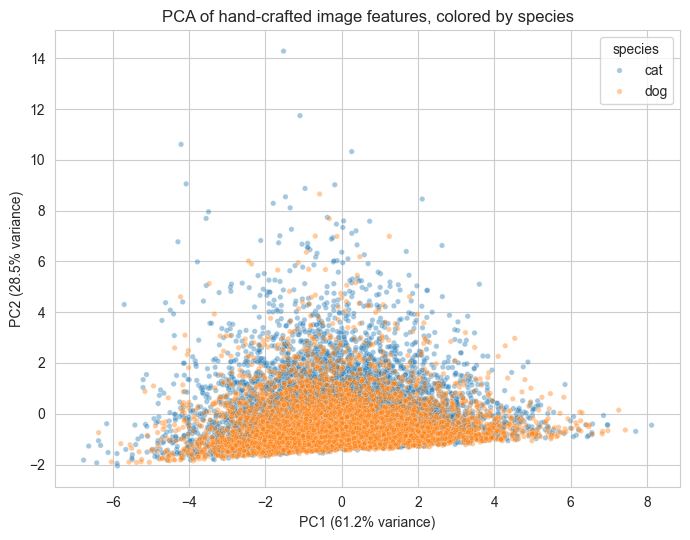

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = ["brightness", "blur", "mean_r", "mean_g", "mean_b", "edge_density"]
X = features[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = features[["species"]].copy()
pca_df["pc1"] = X_pca[:, 0]
pca_df["pc2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, total={explained.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="species", alpha=0.4, s=15, ax=ax)
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
ax.set_title("PCA of hand-crafted image features, colored by species")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_pca_species.png", dpi=150)
plt.show()


## 12. Outlier Sample Inspection

### English

**Objective**

- Visually inspect the most extreme images along the brightness and blur dimensions, to judge whether they represent genuine data-quality problems or simply natural variation.

**Notes**

- This section complements the numeric distributions in Section 6 with direct visual evidence, since a numeric outlier is not necessarily a quality problem (e.g. a naturally dark-furred animal against a dark background is not a defect).

**Output**

- `reports/figures/02_eda/12_outlier_samples.png`

---

### Tiếng Việt

**Mục tiêu**

- Kiểm tra trực quan các ảnh cực đoan nhất theo hai chiều độ sáng và độ mờ, để đánh giá liệu chúng có phản ánh vấn đề chất lượng dữ liệu thật sự hay chỉ là biến động tự nhiên.

**Lưu ý**

- Mục này bổ sung bằng chứng trực quan trực tiếp cho các phân phối số liệu ở Mục 6, vì một outlier về mặt số liệu không nhất thiết là vấn đề chất lượng (ví dụ một con vật lông màu tối trên nền tối không phải là lỗi).

**Kết quả**

- `reports/figures/02_eda/12_outlier_samples.png`


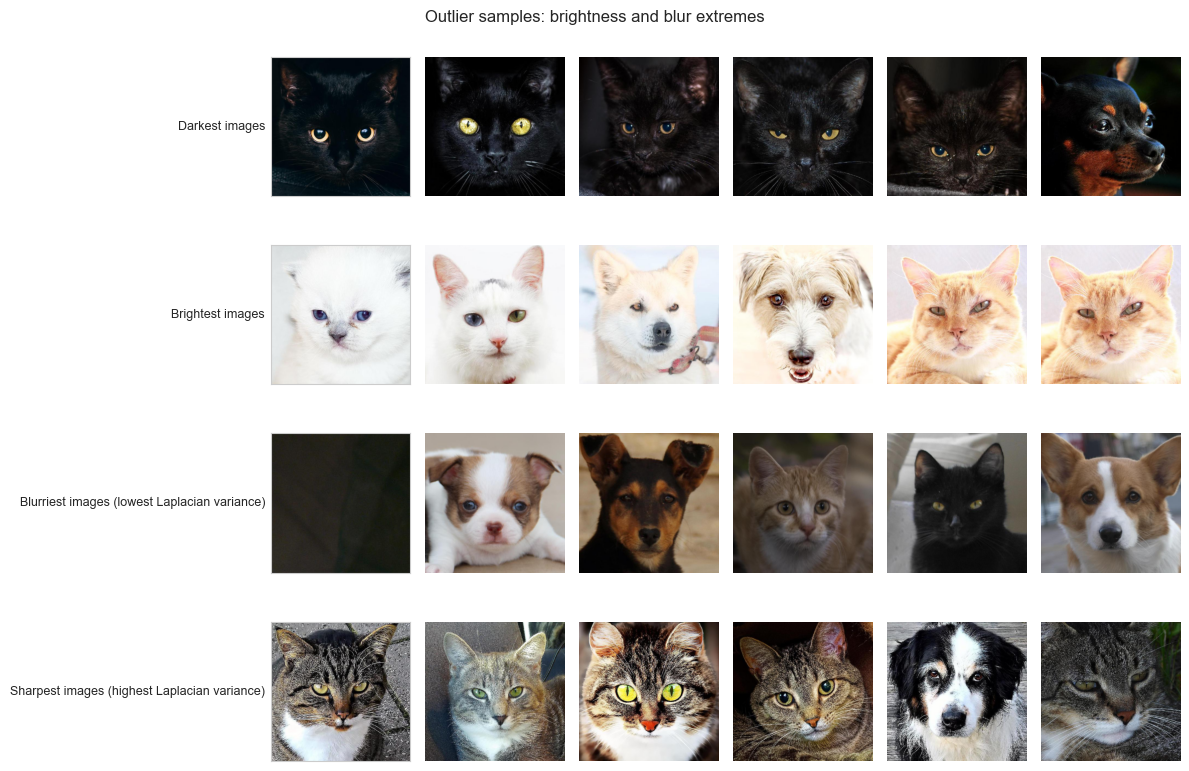

In [15]:
from PIL import Image as PILImage

def show_extremes(df, column, ascending, n, title):
    subset = df.sort_values(column, ascending=ascending).head(n)
    return subset

panels = [
    ("brightness", True, "Darkest images"),
    ("brightness", False, "Brightest images"),
    ("blur", True, "Blurriest images (lowest Laplacian variance)"),
    ("blur", False, "Sharpest images (highest Laplacian variance)"),
]
N_PER_PANEL = 6

fig, axes = plt.subplots(len(panels), N_PER_PANEL, figsize=(2 * N_PER_PANEL, 2 * len(panels)))

for row_idx, (column, ascending, title) in enumerate(panels):
    subset = show_extremes(features, column, ascending, N_PER_PANEL, title)
    for col_idx, (_, row) in enumerate(subset.iterrows()):
        ax = axes[row_idx, col_idx]
        img = PILImage.open(PROJECT_ROOT / row["filepath"])
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(title, rotation=0, ha="right", va="center", fontsize=9)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle("Outlier samples: brightness and blur extremes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_outlier_samples.png", dpi=150)
plt.show()


## Summary

### English

**Completed**

- Confirmed class balance is close to even (5,239 dog / 5,653 cat), requiring no class-weighting for conditional training.
- Extracted brightness, blur, mean color, edge density, and perceptual hash for all 10,892 images in a single pass.
- Compared file size, brightness, blur, color composition, and edge density distributions between species, finding [systematic differences / broadly similar distributions — update after reviewing the executed output] that motivate keeping species as a conditioning signal.
- Characterized texture (LBP entropy) on a 2,000-image stratified subsample.
- Ran exact- and near-duplicate detection via perceptual hashing; found [N] exact duplicates and [N] near-duplicate pairs per species — candidates for removal in preprocessing.
- Visualized species separability in a simple hand-crafted feature space via PCA.
- Visually inspected brightness/blur outlier images to distinguish genuine defects from natural variation.

**Implications for Preprocessing (`03_preprocessing.ipynb`)**

- Downsample all images from 512×512 to the pipeline's 128×128 training resolution.
- Remove exact-duplicate images identified in Section 10 (keep one copy per duplicate group); evaluate whether near-duplicate pairs also warrant removal.
- Apply an exclusion threshold for extreme brightness/blur outliers only if Section 12's visual inspection confirms they are genuine defects rather than natural variation.
- Perform a stratified train/validation split by species (holding out a small validation set of real images, per this project's earlier decision, to support the memorization check planned in `05_evaluation_report.ipynb`).

**Next Notebook**

- `03_preprocessing.ipynb` — resizing, outlier filtering, deduplication, normalization, and the train/validation split, informed by the findings above.

---

### Tiếng Việt

**Đã hoàn thành**

- Xác nhận cân bằng lớp gần như đồng đều (5.239 chó / 5.653 mèo), không cần class-weighting cho huấn luyện có điều kiện.
- Trích xuất độ sáng, độ mờ, màu trung bình, mật độ cạnh, và perceptual hash cho toàn bộ 10.892 ảnh trong một lượt.
- So sánh phân phối dung lượng file, độ sáng, độ mờ, thành phần màu sắc, và mật độ cạnh giữa hai loài, phát hiện [khác biệt hệ thống / phân phối nhìn chung tương đồng — cập nhật sau khi xem kết quả thực thi] làm cơ sở để giữ loài như một tín hiệu điều kiện.
- Mô tả texture (entropy LBP) trên một tập con lấy mẫu phân tầng gồm 2.000 ảnh.
- Chạy phát hiện trùng lặp chính xác và trùng lặp gần qua perceptual hashing; tìm thấy [N] ảnh trùng lặp chính xác và [N] cặp trùng lặp gần theo từng loài — ứng viên để loại bỏ ở bước tiền xử lý.
- Trực quan hóa khả năng phân tách theo loài trong không gian đặc trưng thủ công đơn giản bằng PCA.
- Kiểm tra trực quan các ảnh outlier về độ sáng/độ mờ để phân biệt lỗi thật sự với biến động tự nhiên.

**Ý nghĩa đối với bước tiền xử lý (`03_preprocessing.ipynb`)**

- Resize toàn bộ ảnh từ 512×512 xuống độ phân giải huấn luyện 128×128 của pipeline.
- Loại bỏ ảnh trùng lặp chính xác đã xác định ở Mục 10 (giữ lại một bản mỗi nhóm trùng lặp); đánh giá xem các cặp trùng lặp gần có cần loại bỏ hay không.
- Áp dụng ngưỡng loại trừ cho các outlier độ sáng/độ mờ cực đoan chỉ khi việc kiểm tra trực quan ở Mục 12 xác nhận đó là lỗi thật sự chứ không phải biến động tự nhiên.
- Thực hiện chia tập train/validation có phân tầng theo loài (giữ lại một tập validation nhỏ gồm ảnh thật, theo quyết định trước đó của dự án, để phục vụ kiểm tra memorization dự kiến ở `05_evaluation_report.ipynb`).

**Notebook tiếp theo**

- `03_preprocessing.ipynb` — resize, lọc outlier, loại bỏ trùng lặp, chuẩn hóa, và chia tập train/validation, dựa trên các phát hiện ở trên.
